# 1 Dataset do Projeto

# Camada Raw: Ingestão e Exploração Inicial

Este dataset contém preços históricos e atuais de veículos comercializados no Brasil, baseados na **Tabela FIPE** (Fundação Instituto de Pesquisas Econômicas). Os dados foram extraídos e organizados pelo projeto **fipeX**, uma iniciativa independente criada para facilitar o acesso a dados automotivos públicos de forma estruturada.

---

### Sobre o Dataset
Este conjunto de dados fornece a base necessária para:

* **Análise de depreciação de veículos:** Avaliação da variação de valor dos modelos ao longo do tempo.
* **Previsão de preços (Machine Learning):** Desenvolvimento de modelos preditivos baseados em séries temporais.
* **Estudos econômicos:** Análise do mercado automotivo brasileiro e seu comportamento histórico.
* **Aplicações de BI:** Criação de dashboards para consulta e suporte à tomada de decisão.

---

In [34]:
import pandas as pd

In [35]:
df = pd.read_parquet('fipex-prices-latest-merged.parquet')
df.head()

,tipo_veiculo,codigo_fipe,nome_modelo,nome_marca,nome_combustivel,sigla_combustivel,ano_modelo,zero_km,valor_centavos,valor_formatado,mes_referencia,ano_referencia
0,moto,840015-6,ATV 100,ADLY,Gasolina,g,1990.0,False,0,"R$ 0,00",9,2012
1,moto,840015-6,ATV 100,ADLY,Gasolina,g,1991.0,False,0,"R$ 0,00",9,2012
2,moto,840015-6,ATV 100,ADLY,Gasolina,g,1992.0,False,0,"R$ 0,00",9,2012
3,moto,840015-6,ATV 100,ADLY,Gasolina,g,1993.0,False,0,"R$ 0,00",9,2012
4,moto,840015-6,ATV 100,ADLY,Gasolina,g,1994.0,False,0,"R$ 0,00",9,2012


In [36]:
df.tail()

,tipo_veiculo,codigo_fipe,nome_modelo,nome_marca,nome_combustivel,sigla_combustivel,ano_modelo,zero_km,valor_centavos,valor_formatado,mes_referencia,ano_referencia
9276116,carro,072001-1,fortwo passion coupé 1.0 62kw,smart,Gasolina,g,NaN,True,5862800,"R$ 58.628,00",10,2009
9276117,carro,072001-1,fortwo passion coupé 1.0 62kw,smart,Gasolina,g,NaN,True,5828900,"R$ 58.289,00",9,2009
9276118,carro,072001-1,fortwo passion coupé 1.0 62kw,smart,Gasolina,g,NaN,True,5807600,"R$ 58.076,00",8,2009
9276119,carro,072001-1,fortwo passion coupé 1.0 62kw,smart,Gasolina,g,NaN,True,5781500,"R$ 57.815,00",7,2009
9276120,carro,072001-1,fortwo passion coupé 1.0 62kw,smart,Gasolina,g,NaN,True,5830000,"R$ 58.300,00",6,2009


### Colunas do DATASET

In [49]:
df.columns

Index(['tipo_veiculo', 'codigo_fipe', 'nome_modelo', 'nome_marca',
       'nome_combustivel', 'sigla_combustivel', 'ano_modelo', 'zero_km',
       'valor_centavos', 'valor_formatado', 'mes_referencia',
       'ano_referencia'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9276121 entries, 0 to 9276120
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   tipo_veiculo       object 
 1   codigo_fipe        object 
 2   nome_modelo        object 
 3   nome_marca         object 
 4   nome_combustivel   object 
 5   sigla_combustivel  object 
 6   ano_modelo         float64
 7   zero_km            bool   
 8   valor_centavos     int64  
 9   valor_formatado    object 
 10  mes_referencia     int32  
 11  ano_referencia     int32  
dtypes: bool(1), float64(1), int32(2), int64(1), object(7)
memory usage: 716.6+ MB


In [38]:
df.describe()

,ano_modelo,valor_centavos,mes_referencia,ano_referencia
count,8.777727e+06,9.276121e+06,9.276121e+06,9.276121e+06
mean,2.003867e+03,9.030646e+06,6.463552e+00,2.015861e+03
std,9.399621e+00,2.128053e+07,3.470425e+00,6.828119e+00
min,1.981000e+03,0.000000e+00,1.000000e+00,2.001000e+03
25%,1.997000e+03,1.749200e+06,3.000000e+00,2.011000e+03
50%,2.003000e+03,3.811800e+06,6.000000e+00,2.017000e+03
75%,2.011000e+03,8.800500e+06,9.000000e+00,2.022000e+03
max,2.027000e+03,9.603000e+08,1.200000e+01,2.026000e+03


In [39]:
df.isna().sum()

tipo_veiculo              0
codigo_fipe               0
nome_modelo               0
nome_marca                0
nome_combustivel          0
sigla_combustivel         0
ano_modelo           498394
zero_km                   0
valor_centavos            0
valor_formatado           0
mes_referencia            0
ano_referencia            0
dtype: int64

## Análise de Marcas

In [41]:
len(df['nome_marca'].unique())

231

In [40]:
df['nome_marca'].unique()

marcas = pd.DataFrame(df['nome_marca'].unique(), columns =['Marca'])
marcas

,Marca
0,ADLY
1,AGRALE
2,AM Gen
3,AMAZONAS
4,APRILIA
...,...
226,YAMAHA
227,ZEEKR
228,ZONTES
229,byCristo


### Distribuição de marcas

In [42]:
df['nome_marca'].value_counts()

nome_marca
VW - VolksWagen    592657
GM - Chevrolet     563803
MERCEDES-BENZ      514684
Ford               513080
Fiat               495293
                    ...  
Mobílli                32
Leapmotor              30
LEVA                   30
Jetour                 24
Denza                   4
Name: count, Length: 231, dtype: int64

#### Porcentagem

In [68]:
distribuicao_marcas = (df['nome_marca'].value_counts(normalize=True) * 100).round(2).reset_index()
distribuicao_marcas.columns = ['Marca', 'Porcentagem (%)']

contagem_modelos = df.groupby('nome_marca')['nome_modelo'].nunique().reset_index()
contagem_modelos.columns = ['Marca', 'QTD Modelos']

distribuicao_marcas = pd.merge(distribuicao_marcas,contagem_modelos, on='Marca')
distribuicao_marcas.head(10)

,Marca,Porcentagem (%),QTD Modelos
0,VW - VolksWagen,6.39,547
1,GM - Chevrolet,6.08,551
2,MERCEDES-BENZ,5.55,304
3,Ford,5.53,492
4,Fiat,5.34,583
5,Mercedes-Benz,4.25,549
6,SCANIA,3.53,433
7,BMW,3.47,455
8,VOLKSWAGEN,2.93,201
9,FORD,2.90,159


#### Histograma

C:\Users\nicol\AppData\Local\Temp\ipykernel_5808\1119032562.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


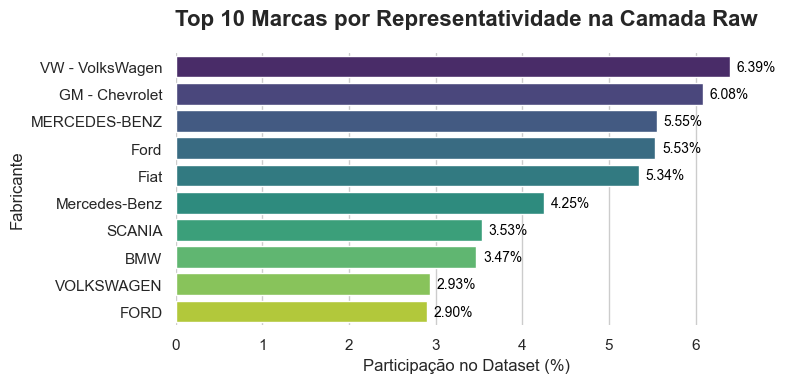

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de estilo (Estética profissional)
sns.set_theme(style="whitegrid") # Fundo branco com linhas de grade suaves
plt.figure(figsize=(8, 4))      # Define o tamanho da imagem

# 2. Criando o gráfico de barras (Top 10 marcas)
# Usamos o head(10) para o gráfico não ficar poluído com 231 marcas
grafico = sns.barplot(
    data=distribuicao_marcas.head(10), 
    x='Porcentagem (%)', 
    y='Marca', 
    palette='viridis' # Degradê de cores moderno
)

# 3. Adicionando os rótulos de dados (O valor em cima da barra)
# Isso facilita a leitura sem precisar olhar pro eixo X
for i in grafico.containers:
    grafico.bar_label(i, fmt='%.2f%%', padding=5, fontsize=10, color='black')

# 4. Títulos e Labels (Padrão Engenharia)
plt.title('Top 10 Marcas por Representatividade na Camada Raw', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Participação no Dataset (%)', fontsize=12)
plt.ylabel('Fabricante', fontsize=12)

# 5. Ajuste final (Remove bordas desnecessárias)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Exibir o gráfico
plt.show()

## Analise de Anos 

In [45]:
df['ano_referencia'].unique()

array([2012, 2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017,
       2016, 2015, 2014, 2013, 2011, 2010, 2009, 2008, 2007, 2006, 2005,
       2004, 2003, 2002, 2001], dtype=int32)

In [46]:
df['ano_referencia'].value_counts()

ano_referencia
2025    584410
2024    564378
2023    547336
2022    527075
2021    512843
2020    495321
2019    477054
2018    457858
2017    441322
2016    422727
2015    403223
2014    381172
2013    362485
2012    343110
2011    320376
2010    299752
2009    279941
2008    262443
2007    245932
2006    228813
2005    211732
2026    199565
2004    197349
2003    185851
2002    172862
2001    151191
Name: count, dtype: int64

## Análise Tipos de Veículo

In [52]:
tipos_veiculo = df['tipo_veiculo'].unique()
tipos_veiculo

array(['moto', 'caminhão', 'carro'], dtype=object)

### Distribuição tipo de Veiculo

In [59]:
distribuicao_tipo_veiculo = (df['tipo_veiculo'].value_counts(normalize = True) * 100).round(2).reset_index()

distribuicao_tipo_veiculo.columns = ['Tipo', 'Porcentagem (%)']
distribuicao_tipo_veiculo

,Tipo,Porcentagem (%)
0,carro,61.56
1,caminhão,22.74
2,moto,15.70


## Análise Combustiveis

In [47]:
df['nome_combustivel'].unique()

array(['Gasolina', 'Diesel', 'Elétrico', 'Flex', 'Híbrido', 'Álcool',
       'Gás Natural'], dtype=object)

### Distribuição Combústiveis

In [63]:
distribuicao_combustiveis = (df['nome_combustivel'].value_counts(normalize = True) * 100).round(2).reset_index()

distribuicao_combustiveis.columns = ['Combustivel', 'Porcentagem (%)']
distribuicao_combustiveis

,Combustivel,Porcentagem (%)
0,Gasolina,55.07
1,Diesel,32.66
2,Flex,10.01
3,Álcool,1.41
4,Híbrido,0.48
5,Elétrico,0.31
6,Gás Natural,0.05


## Análise de Preços


In [88]:
media_ajustada = df[df['valor_centavos'] > 0].copy()
media_ajustada['valor_reais'] = media_ajustada['valor_centavos'] / 100

marcas_com_maiores_medias = media_ajustada.groupby('nome_marca')['valor_reais'].mean().sort_values(ascending = False)
marcas_com_maiores_medias.head(10)

nome_marca
Rolls-Royce    R$ 3,386,610.36
Mclaren        R$ 2,871,191.93
LAMBORGHINI    R$ 2,665,417.29
ASTON MARTIN   R$ 1,265,499.43
Ferrari        R$ 1,119,538.14
ARROW            R$ 601,048.33
DAF              R$ 511,141.90
Porsche          R$ 441,284.44
Denza            R$ 414,200.00
ZEEKR            R$ 372,377.56
Name: valor_reais, dtype: float64

In [93]:
marcas_com_menores_medias = media_ajustada.groupby('nome_marca')['valor_reais'].mean().sort_values(ascending = True)
marcas_com_menores_medias.head(10)

nome_marca
CALOI               R$ 898.22
HERO              R$ 1,040.82
BRANDY            R$ 1,517.41
ORCA              R$ 1,950.99
ATALA             R$ 2,143.78
HARTFORD          R$ 2,295.12
EMME              R$ 2,312.39
L'AQUILA          R$ 2,504.96
JIAPENG VOLCANO   R$ 2,628.10
DAELIM            R$ 2,735.25
Name: valor_reais, dtype: float64